# 02 — Data Cleaning & Feature Engineering

Turn the 4 raw ufcstats scrapes (`data/raw/`) into a leak-free, model-ready train/test set (`data/processed/`).

**Pipeline:**
1. Load & type-cast all 4 raw CSVs
2. Merge event dates onto fights
3. Filter to valid win/loss outcomes
4. Impute missing reach from height
5. Pivot fight stats to one row per fight
6. Point-in-time career features (the anti-leakage core)
6b. Recent form (last 3), a debut flag, and Elo ratings
7. Symmetric difference features + random corner swap
8. Temporal train/test split

**Two non-negotiable rules enforced here:**
- **No fight's own stats ever feed its own features.** Per-fight stats (strikes, takedowns, control time) describe the fight we're predicting — they may only contribute to *career history* for **later** fights.
- **No corner-assignment leakage.** The favorite is conventionally listed first, so we randomize which fighter is "a" and use symmetric a−b difference features.

## 1. Load & type-cast

ufcstats encodes "no data" as the string `'--'` — we read that as NaN everywhere. Then parse:
- `height` `5' 10"` → inches, `reach` `71"` → inches
- `dob` (`Sep 07, 1994`) and event `date` (`March 11, 1994`) → datetime
- `control_time` / fight `time` (`m:ss`) → seconds (untracked `'--'` stays NaN, **not** 0)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_RAW = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
RNG_SEED = 42

NA = ['--']  # ufcstats' universal "no data" placeholder
events   = pd.read_csv(DATA_RAW / 'raw_events.csv', na_values=NA)
fights   = pd.read_csv(DATA_RAW / 'raw_fights.csv', na_values=NA)
stats    = pd.read_csv(DATA_RAW / 'raw_fight_stats.csv', na_values=NA)
fighters = pd.read_csv(DATA_RAW / 'raw_fighters.csv', na_values=NA)


def height_to_inches(h):
    if pd.isna(h):
        return np.nan
    feet, inches = h.replace('"', '').split("'")
    return int(feet) * 12 + int(inches)


def reach_to_inches(r):
    return np.nan if pd.isna(r) else float(str(r).replace('"', ''))


def mmss_to_seconds(t):
    if pd.isna(t):
        return np.nan
    m, s = str(t).split(':')
    return int(m) * 60 + int(s)


fighters['height_in'] = fighters['height'].map(height_to_inches)
fighters['reach_in']  = fighters['reach'].map(reach_to_inches)
fighters['dob']       = pd.to_datetime(fighters['dob'], format='%b %d, %Y')
events['date']        = pd.to_datetime(events['date'], format='%B %d, %Y')
stats['control_time_sec'] = stats['control_time'].map(mmss_to_seconds)
fights['time_sec']    = fights['time'].map(mmss_to_seconds)

In [2]:
# sanity check: shapes and how much each parsed column is missing
for name, df in [('events', events), ('fights', fights), ('stats', stats), ('fighters', fighters)]:
    print(f'{name:<9} {df.shape}')
print()
print('missing after parsing:')
print('  fighters.height_in :', fighters['height_in'].isna().sum())
print('  fighters.reach_in  :', fighters['reach_in'].isna().sum())
print('  fighters.dob       :', fighters['dob'].isna().sum())
print('  stats.control_time :', stats['control_time_sec'].isna().sum(), '(untracked, older fights)')
print()
fighters[['name', 'height', 'height_in', 'reach', 'reach_in', 'dob']].head(3)

events    (775, 4)
fights    (8659, 11)
stats     (17276, 25)
fighters  (2710, 8)

missing after parsing:
  fighters.height_in : 21
  fighters.reach_in  : 655
  fighters.dob       : 103
  stats.control_time : 362 (untracked, older fights)



,name,height,height_in,reach,reach_in,dob
0,AJ Cunningham,"5' 10""",70.0,"71""",71.0,1994-09-07
1,AJ Dobson,"6' 1""",73.0,"76""",76.0,1992-01-18
2,AJ Fletcher,"5' 10""",70.0,"67""",67.0,1997-02-18


## 2. Merge event date onto fights

`raw_fights` has no date of its own — join to `raw_events` on `event_id` so every fight carries its real date. Everything downstream (point-in-time features, temporal split) depends on this.

In [3]:
fights = fights.merge(events[['event_id', 'date']], on='event_id', how='left', validate='m:1')
assert fights['date'].notna().all(), 'every fight must have a date'

print(f"{len(fights)} fights spanning {fights['date'].min().date()} -> {fights['date'].max().date()}")
fights[['fight_id', 'date', 'fighter_a_id', 'fighter_b_id', 'winner_id', 'method']].head(3)

8659 fights spanning 1994-03-11 -> 2026-06-27


,fight_id,date,fighter_a_id,fighter_b_id,winner_id,method
0,00835554f95fa911,1994-03-11,429e7d3725852ce9,46c8ec317aff28ac,429e7d3725852ce9,KO/TKO
1,aa161c7159741766,1994-03-11,429e7d3725852ce9,749685d24e2cac50,429e7d3725852ce9,Submission
2,8fbdde20b712b8da,1994-03-11,46c8ec317aff28ac,319fa1bd3176bded,46c8ec317aff28ac,Submission


## 3. Filter to valid outcomes

Drop fights with no `winner_id` (draws / no-contests) and fights whose method isn't a clean win/loss (Overturned, Could Not Continue, DQ, Other). What's kept: the three decision types, KO/TKO, Submission, and Doctor's Stoppage.

In [4]:
VALID_METHODS = [
    'Decision - Unanimous', 'Decision - Split', 'Decision - Majority',
    'KO/TKO', 'Submission', "TKO - Doctor's Stoppage",
]

n_before = len(fights)
no_winner = fights['winner_id'].isna()
bad_method = ~fights['method'].isin(VALID_METHODS)
print(f'dropping {no_winner.sum()} fights with no winner (draw/NC)')
print(f'dropping {(bad_method & ~no_winner).sum()} more with a non-clean method:')
print(fights.loc[bad_method & ~no_winner, 'method'].value_counts().to_string())

fights = fights[~no_winner & ~bad_method].copy()
print(f'\n{n_before} -> {len(fights)} fights kept')
print()
print(fights['method'].value_counts().to_string())

dropping 154 fights with no winner (draw/NC)
dropping 23 more with a non-clean method:
method
DQ    23

8659 -> 8482 fights kept

method
Decision - Unanimous       3101
KO/TKO                     2732
Submission                 1686
Decision - Split            801
TKO - Doctor's Stoppage      96
Decision - Majority          66


## 4. Impute missing reach

~24% of fighters (655/2710) have no reach on ufcstats — mostly older fighters. Reach is strongly linear in height, so instead of dropping them we fit a height→reach regression on the fighters who have both and predict the gaps. A `reach_imputed` flag records which values are estimates. (The 21 fighters missing height too fall back to the median reach.)

reach = 1.055 * height + -2.13   (R^2 = 0.794)
filled 635 from height, 20 from median


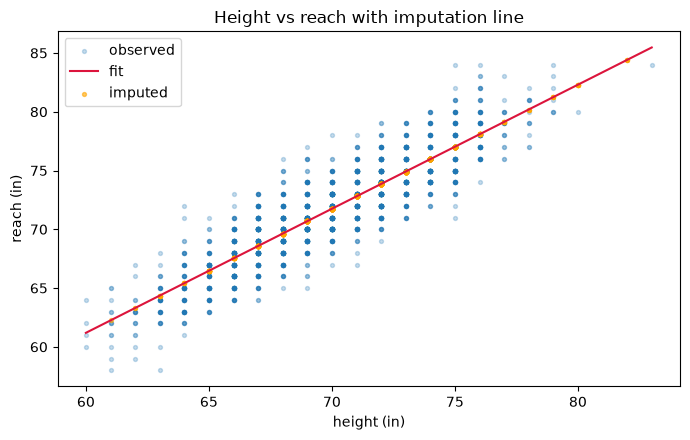

In [5]:
from sklearn.linear_model import LinearRegression

have_both = fighters['height_in'].notna() & fighters['reach_in'].notna()
reg = LinearRegression().fit(fighters.loc[have_both, ['height_in']],
                             fighters.loc[have_both, 'reach_in'])
r2 = reg.score(fighters.loc[have_both, ['height_in']], fighters.loc[have_both, 'reach_in'])

fighters['reach_imputed'] = fighters['reach_in'].isna()
fill_from_height = fighters['reach_in'].isna() & fighters['height_in'].notna()
fighters.loc[fill_from_height, 'reach_in'] = reg.predict(
    fighters.loc[fill_from_height, ['height_in']])
n_median = fighters['reach_in'].isna().sum()  # missing height too
fighters['reach_in'] = fighters['reach_in'].fillna(fighters['reach_in'].median())

print(f'reach = {reg.coef_[0]:.3f} * height + {reg.intercept_:.2f}   (R^2 = {r2:.3f})')
print(f'filled {fill_from_height.sum()} from height, {n_median} from median')
assert fighters['reach_in'].notna().all()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(fighters.loc[have_both, 'height_in'], fighters.loc[have_both, 'reach_in'],
           s=8, alpha=0.25, label='observed')
xs = pd.DataFrame({'height_in': np.linspace(fighters['height_in'].min(),
                                            fighters['height_in'].max(), 50)})
ax.plot(xs['height_in'], reg.predict(xs), color='crimson', label='fit')
ax.scatter(fighters.loc[fill_from_height, 'height_in'], fighters.loc[fill_from_height, 'reach_in'],
           s=8, color='orange', alpha=0.6, label='imputed')
ax.set_xlabel('height (in)'); ax.set_ylabel('reach (in)')
ax.set_title('Height vs reach with imputation line'); ax.legend()
plt.tight_layout(); plt.show()

## 5. Pivot fight stats to one row per fight

`raw_fight_stats` is one row per **fighter** per fight; reshape to one row per **fight** with `_a` / `_b` column suffixes matching the fight's fighter_a/fighter_b.

Two things to be careful about:
- `control_time_tracked`: control time is `'--'` (untracked) for older fights — that is *unknown*, not a real `0:00`, so we keep it NaN and add a boolean flag.
- **These columns are NOT model features.** They describe the fight being predicted (leakage). They exist only as raw material for the *career history* aggregates in section 6.

8482 fights, 57 columns
fights with no stats at all (very old events): 21


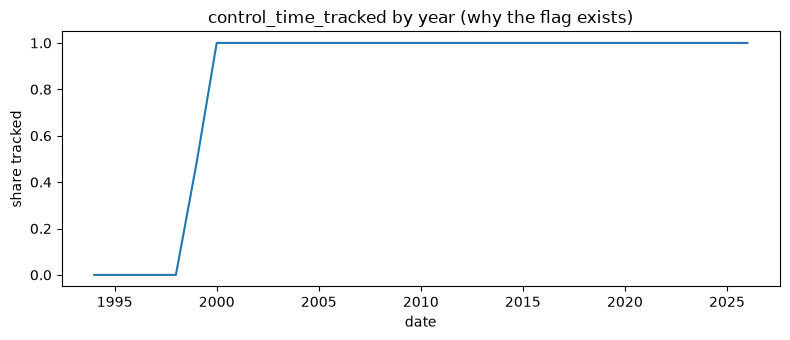

In [6]:
stats['control_time_tracked'] = stats['control_time'].notna()

stat_cols = [c for c in stats.columns if c not in ('fight_id', 'fighter_id', 'control_time')]
sides = fights[['fight_id', 'fighter_a_id', 'fighter_b_id']]
stats_m = stats.merge(sides, on='fight_id')  # inner join: drops stats of filtered-out fights
is_a = stats_m['fighter_id'] == stats_m['fighter_a_id']
is_b = stats_m['fighter_id'] == stats_m['fighter_b_id']
assert (is_a | is_b).all(), 'every stat row must belong to one of the two fighters'
stats_m['side'] = np.where(is_a, 'a', 'b')

wide = stats_m.pivot(index='fight_id', columns='side', values=stat_cols)
wide.columns = [f'{col}_{side}' for col, side in wide.columns]
fights = fights.merge(wide, on='fight_id', how='left')

# one fight-level flag: control time is only usable if tracked for both fighters
fights['control_time_tracked'] = (fights['control_time_tracked_a'].fillna(False)
                                  & fights['control_time_tracked_b'].fillna(False))
fights = fights.drop(columns=['control_time_tracked_a', 'control_time_tracked_b'])

assert fights['fight_id'].is_unique
print(f'{len(fights)} fights, {fights.shape[1]} columns')
print(f"fights with no stats at all (very old events): {fights['sig_str_landed_a'].isna().sum()}")

tracked_by_year = fights.groupby(fights['date'].dt.year)['control_time_tracked'].mean()
fig, ax = plt.subplots(figsize=(8, 3.5))
tracked_by_year.plot(ax=ax)
ax.set_ylabel('share tracked'); ax.set_title('control_time_tracked by year (why the flag exists)')
plt.tight_layout(); plt.show()

## 6. Point-in-time career features — **the anti-leakage core**

For every fight, each fighter's features are built from fights **strictly before** that fight's date. The mechanic: stack to one row per fighter per fight, sort by `(fighter, date)`, then use *shift/cumulative* patterns so row *i* only ever sees rows `< i`:

- counts (`career_fights/wins/losses`): `cumsum() − current_row` ≡ cumulative up to but excluding this fight
- averages (`career_avg_*`): `shift(1).expanding().mean()` — the shift pushes the current fight out of its own window
- `career_win_streak`: the streak counter is appended **before** being updated with the current result

If any of these ever included the current fight, the model would be reading tonight's scorecard. Verified with asserts below.

*(Caveat: early-UFC one-night tournaments put multiple fights on the same date; within a date we order by fight_id, matching bracket order.)*

In [7]:
FINISH_METHODS = ['KO/TKO', 'Submission', "TKO - Doctor's Stoppage"]

# one row per fighter per fight
base_cols = ['fight_id', 'date', 'winner_id', 'method']
long = pd.concat([
    fights[base_cols + ['fighter_a_id']].rename(columns={'fighter_a_id': 'fighter_id'}),
    fights[base_cols + ['fighter_b_id']].rename(columns={'fighter_b_id': 'fighter_id'}),
], ignore_index=True)
long['won'] = (long['fighter_id'] == long['winner_id']).astype(int)
long['won_by_finish'] = ((long['won'] == 1) & long['method'].isin(FINISH_METHODS)).astype(int)

# attach this fighter's own in-fight stats (history fuel only) and static attributes
long = long.merge(
    stats[['fight_id', 'fighter_id', 'sig_str_landed', 'sig_str_att',
           'takedowns_landed', 'takedowns_att', 'sub_att', 'control_time_sec']],
    on=['fight_id', 'fighter_id'], how='left')
long = long.merge(fighters[['fighter_id', 'dob', 'height_in', 'reach_in', 'reach_imputed']],
                  on='fighter_id', how='left')

long = long.sort_values(['fighter_id', 'date', 'fight_id']).reset_index(drop=True)
g = long.groupby('fighter_id', sort=False)

# --- counts: cumulative-minus-current == strictly-prior totals
long['career_fights'] = g.cumcount()
long['career_wins']   = g['won'].cumsum() - long['won']
long['career_losses'] = long['career_fights'] - long['career_wins']
long['career_win_rate'] = long['career_wins'] / long['career_fights'].replace(0, np.nan)
prior_finishes = g['won_by_finish'].cumsum() - long['won_by_finish']
long['career_finish_rate'] = (prior_finishes / long['career_wins'].replace(0, np.nan)).fillna(0)

# --- averages: shift(1) pushes the current fight out of its own window
for col in ['sig_str_landed', 'sig_str_att', 'takedowns_landed', 'takedowns_att',
            'sub_att', 'control_time_sec']:
    long[f'career_avg_{col}'] = g[col].transform(lambda s: s.shift(1).expanding().mean())


# --- streak entering the fight: append BEFORE updating with the current result
def prior_win_streak(won):
    streak, out = 0, []
    for w in won:
        out.append(streak)
        streak = streak + 1 if w == 1 else 0
    return pd.Series(out, index=won.index)


long['career_win_streak'] = g['won'].transform(prior_win_streak)

long['days_since_last'] = (long['date'] - g['date'].shift(1)).dt.days
long['age_at_fight'] = (long['date'] - long['dob']).dt.days / 365.25

In [8]:
# leakage sanity check 1: every debut must show an empty record
# (head(1) = literal first row; .first() would skip NaNs and backfill days_since_last)
debuts = long.groupby('fighter_id').head(1)
assert (debuts['career_fights'] == 0).all()
assert (debuts['career_wins'] == 0).all()
assert (debuts['career_win_streak'] == 0).all()
assert debuts['days_since_last'].isna().all()

# leakage sanity check 2: career totals lag results by exactly one fight
chk = long.sort_values(['fighter_id', 'date'])
chk_shifted = chk.groupby('fighter_id')['won'].cumsum().groupby(chk['fighter_id']).shift(1).fillna(0)
assert (chk['career_wins'] == chk_shifted).all(), 'career_wins must equal wins through the PREVIOUS fight'

# eyeball it on the busiest fighter: career_wins/streak reflect results only up to the row above
busiest = long['fighter_id'].value_counts().idxmax()
name = fighters.loc[fighters['fighter_id'] == busiest, 'name'].iloc[0]
print(f'most-active fighter: {name} ({long["fighter_id"].eq(busiest).sum()} fights)\n')
cols = ['date', 'won', 'career_fights', 'career_wins', 'career_losses',
        'career_win_streak', 'days_since_last']
print(long.loc[long['fighter_id'] == busiest, cols].head(10).to_string(index=False))

most-active fighter: Jim Miller (46 fights)

      date  won  career_fights  career_wins  career_losses  career_win_streak  days_since_last
2008-10-18    1              0            0              0                  0              NaN
2008-12-10    1              1            1              0                  1             53.0
2009-03-07    0              2            2              0                  2             87.0
2009-07-11    1              3            2              1                  0            126.0
2009-09-19    1              4            3              1                  1             70.0
2010-01-02    1              5            4              1                  2            105.0
2010-03-27    1              6            5              1                  3             84.0
2010-09-15    1              7            6              1                  4            172.0
2010-12-11    1              8            7              1                  5             87.0
2011-

### 6b. Recent form, debut flag & Elo

Three more point-in-time signals, built with the same *strictly-before* discipline as section 6:

- **`is_debut`** — flags a fighter's first bout. Section 7 fills undefined career stats with 0, which is ambiguous ("no history" vs. a genuine average of 0); this flag lets the model tell the two apart. Carried per corner, like `reach_imputed`.
- **`recent_win_rate_3` / `recent_finish_rate_3`** — rolling form over the previous **3** fights (`shift(1)` drops the current one). Career averages dilute a hot or cold streak; a last-3 window captures current form.
- **`elo`** — each fighter's Elo rating *entering* the fight (start 1500, K=32), updated fight-by-fight in chronological order. Unlike a raw win rate, Elo encodes **strength of schedule**: beating a highly-rated opponent moves the needle more than beating a journeyman.

Leak-safety is re-checked below: a debut must enter at Elo 1500 with no recent-form history.

In [9]:
# --- 6b. Recent form, debut flag, and Elo — all strictly pre-fight (no leakage) ---
from collections import defaultdict

g = long.groupby('fighter_id', sort=False)  # long stays sorted by (fighter_id, date, fight_id)

# debut flag: no prior fights -> career stats are undefined, not zero
long['is_debut'] = (long['career_fights'] == 0).astype(int)

# recent form over the previous up-to-3 fights; shift(1) drops the current fight
long['recent_win_rate_3']    = g['won'].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
long['recent_finish_rate_3'] = g['won_by_finish'].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())

# Elo entering each fight: walk kept fights in chronological order, record the PRE-fight
# rating for both fighters, then update with the result (start 1500, K=32).
K, BASE_ELO = 32.0, 1500.0
elo = defaultdict(lambda: BASE_ELO)
rows = []
cols = ['fight_id', 'fighter_a_id', 'fighter_b_id', 'winner_id', 'date']
for f in fights[cols].sort_values(['date', 'fight_id']).itertuples(index=False):
    ra, rb = elo[f.fighter_a_id], elo[f.fighter_b_id]
    rows.append((f.fight_id, f.fighter_a_id, ra))
    rows.append((f.fight_id, f.fighter_b_id, rb))
    sa = 1.0 if f.winner_id == f.fighter_a_id else 0.0     # fights are filtered to clean win/loss
    ea = 1.0 / (1.0 + 10 ** ((rb - ra) / 400.0))
    elo[f.fighter_a_id] = ra + K * (sa - ea)
    elo[f.fighter_b_id] = rb + K * ((1.0 - sa) - (1.0 - ea))
elo_pre = pd.DataFrame(rows, columns=['fight_id', 'fighter_id', 'elo'])
long = long.merge(elo_pre, on=['fight_id', 'fighter_id'], how='left', validate='1:1')

# leak checks: a debut enters at base Elo with no recent-form history
_d = long.groupby('fighter_id').head(1)
assert (_d['is_debut'] == 1).all()
assert _d['recent_win_rate_3'].isna().all() and _d['recent_finish_rate_3'].isna().all()
assert (_d['elo'] == BASE_ELO).all() and long['elo'].notna().all()

_top = long.loc[long['elo'].idxmax()]
_top_name = fighters.loc[fighters['fighter_id'] == _top['fighter_id'], 'name'].iloc[0]
print('added: is_debut, recent_win_rate_3, recent_finish_rate_3, elo')
print(f"Elo entering a fight -- min {long['elo'].min():.0f} / median {long['elo'].median():.0f} / max {long['elo'].max():.0f}")
print(f"peak pre-fight Elo: {_top_name} ({_top['elo']:.0f}) on {_top['date'].date()}")

added: is_debut, recent_win_rate_3, recent_finish_rate_3, elo
Elo entering a fight -- min 1422 / median 1516 / max 1771
peak pre-fight Elo: Jon Jones (1771) on 2024-11-16


## 7. Symmetric features + de-biased corner assignment

Red-corner fighters win ~55–58% — because promoters put the favorite in red, not because the corner helps. Worse, ufcstats lists the winner first, so "fighter_a" in the raw scrape is almost a label. Two fixes, both applied:

1. **Random swap** (seeded): per fight, flip which fighter is "a" with p=0.5, so `target = fighter_a won` carries no positional information.
2. **Difference features** (`*_diff = a − b`): the model sees relative advantages, and swapping a/b just flips every sign — the problem is symmetric by construction.

NaNs (debut fighters' career **and** recent-form averages, `days_since_last`, `career_win_rate`) are **left as NaN** on purpose: XGBoost handles them natively, and any imputation for logistic regression must be fit on the *train* split only — that belongs in notebook 03. Two features never go NaN and so aren't differenced: **`elo`** (everyone enters at 1500) and the per-corner flags **`is_debut` / `reach_imputed`**, which are carried as-is so the model knows when history is thin.

In [10]:
FEAT_COLS = [
    'age_at_fight', 'height_in', 'reach_in', 'reach_imputed',
    'career_fights', 'career_wins', 'career_losses', 'career_win_rate',
    'career_win_streak', 'career_finish_rate', 'is_debut',
    'career_avg_sig_str_landed', 'career_avg_sig_str_att',
    'career_avg_takedowns_landed', 'career_avg_takedowns_att',
    'career_avg_sub_att', 'career_avg_control_time_sec',
    'days_since_last', 'recent_win_rate_3', 'recent_finish_rate_3', 'elo',
]

per_fighter = long[['fight_id', 'fighter_id'] + FEAT_COLS]
model_df = fights[['fight_id', 'date', 'weight_class', 'fighter_a_id', 'fighter_b_id',
                   'winner_id', 'method']].copy()
for side in ['a', 'b']:
    side_df = per_fighter.rename(
        columns={'fighter_id': f'fighter_{side}_id', **{c: f'{c}_{side}' for c in FEAT_COLS}})
    model_df = model_df.merge(side_df, on=['fight_id', f'fighter_{side}_id'],
                              how='left', validate='1:1')

raw_a_win_rate = (model_df['winner_id'] == model_df['fighter_a_id']).mean()

# seeded random swap of the a/b roles
rng = np.random.default_rng(RNG_SEED)
swap = rng.random(len(model_df)) < 0.5
swap_pairs = [('fighter_a_id', 'fighter_b_id')] + [(f'{c}_a', f'{c}_b') for c in FEAT_COLS]
for col_a, col_b in swap_pairs:
    model_df.loc[swap, [col_a, col_b]] = model_df.loc[swap, [col_b, col_a]].to_numpy()

model_df['target'] = (model_df['winner_id'] == model_df['fighter_a_id']).astype(int)

# symmetric a-minus-b differences (per-corner flags reach_imputed / is_debut stay un-differenced)
DIFF_BASES = ['age_at_fight', 'height_in', 'reach_in', 'career_fights', 'career_wins',
              'career_losses', 'career_win_rate', 'career_win_streak', 'career_finish_rate',
              'career_avg_sig_str_landed', 'career_avg_sig_str_att',
              'career_avg_takedowns_landed', 'career_avg_takedowns_att',
              'career_avg_sub_att', 'career_avg_control_time_sec', 'days_since_last',
              'recent_win_rate_3', 'recent_finish_rate_3', 'elo']
for base in DIFF_BASES:
    model_df[f'{base}_diff'] = model_df[f'{base}_a'] - model_df[f'{base}_b']

print(f'"fighter_a wins" BEFORE swap: {raw_a_win_rate:.3f}  <- pure position leakage')
print(f'"fighter_a wins" AFTER swap : {model_df["target"].mean():.3f}  <- ~0.50, as it must be')
print(f'\n{model_df.shape[0]} fights x {model_df.shape[1]} columns, '
      f'{len(DIFF_BASES)} diff features')
model_df[['date', 'target', 'reach_in_diff', 'elo_diff', 'recent_win_rate_3_diff', 'career_win_rate_diff']].head()

"fighter_a wins" BEFORE swap: 0.643  <- pure position leakage
"fighter_a wins" AFTER swap : 0.501  <- ~0.50, as it must be

8482 fights x 69 columns, 19 diff features


,date,target,reach_in_diff,elo_diff,recent_win_rate_3_diff,career_win_rate_diff
0,1994-03-11,1,-1.055395,0.000000,NaN,NaN
1,1994-03-11,0,2.110790,-15.263693,0.0,0.0
2,1994-03-11,1,2.110790,17.438774,NaN,NaN
3,1994-03-11,1,2.110790,16.000000,NaN,NaN
4,1994-03-11,0,-5.276975,15.297533,0.5,0.5


## 8. Temporal train/test split

Sort by date, train on the past, test on the future — **never** a random split: career features are cumulative, so a random split would train on fights that happened *after* (and whose fighters' histories contain) test fights. Cutoff: **2024-07-01**, holding out the most recent ~2 years.

train:  7472 fights  1994-03-11 -> 2024-06-29
test :  1010 fights  2024-07-13 -> 2026-06-27  (11.9% of data)
target mean  train=0.498  test=0.523

saved to ../data/processed/: fights_features.csv, train.csv, test.csv


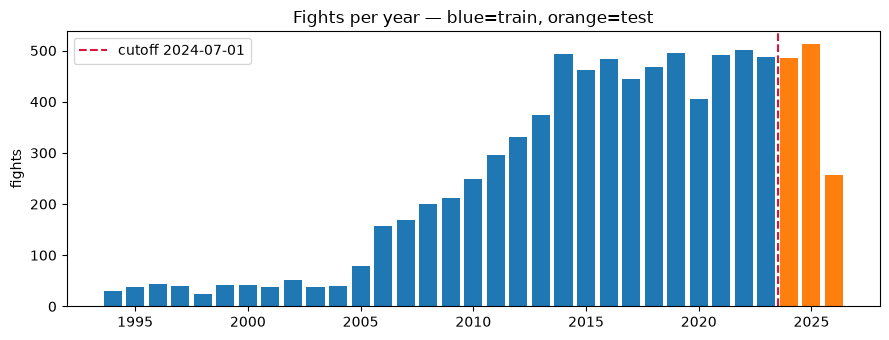

In [11]:
CUTOFF = pd.Timestamp('2024-07-01')

model_df = model_df.sort_values('date').reset_index(drop=True)
train = model_df[model_df['date'] < CUTOFF]
test = model_df[model_df['date'] >= CUTOFF]
assert train['date'].max() < test['date'].min(), 'temporal split must not overlap'

model_df.to_csv(DATA_PROCESSED / 'fights_features.csv', index=False)
train.to_csv(DATA_PROCESSED / 'train.csv', index=False)
test.to_csv(DATA_PROCESSED / 'test.csv', index=False)

print(f'train: {len(train):>5} fights  {train["date"].min().date()} -> {train["date"].max().date()}')
print(f'test : {len(test):>5} fights  {test["date"].min().date()} -> {test["date"].max().date()}'
      f'  ({len(test) / len(model_df):.1%} of data)')
print(f'target mean  train={train["target"].mean():.3f}  test={test["target"].mean():.3f}')
print(f"\nsaved to {DATA_PROCESSED}/: fights_features.csv, train.csv, test.csv")

per_year = model_df.groupby(model_df['date'].dt.year).size()
fig, ax = plt.subplots(figsize=(9, 3.5))
colors = ['tab:blue' if y < CUTOFF.year else 'tab:orange' for y in per_year.index]
ax.bar(per_year.index, per_year.values, color=colors)
ax.axvline(CUTOFF.year - 0.5, color='crimson', ls='--', label=f'cutoff {CUTOFF.date()}')
ax.set_ylabel('fights'); ax.set_title('Fights per year — blue=train, orange=test')
ax.legend()
plt.tight_layout(); plt.show()